### SENTA FITO SITUMORANG - 4222301017
#### Classify digit in Extended MNIST Dataset using SVM

# **1. Dataset Preparation**

In [30]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_predict
from mlxtend.data import loadlocal_mnist

In [31]:
data_images, data_labels = loadlocal_mnist(images_path='dataset/emnist-letters-train-images-idx3-ubyte',
                                            labels_path='dataset/emnist-letters-train-labels-idx1-ubyte')

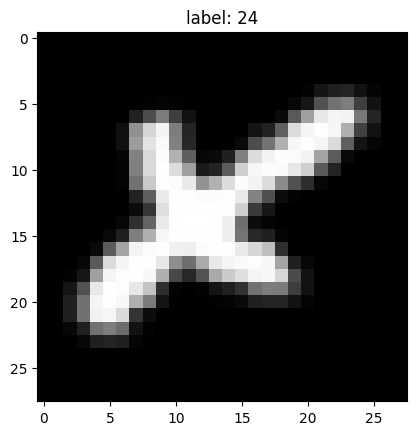

In [32]:
idx = random.randint(0, len(data_images) - 1)
plt.imshow(data_images[idx].reshape(28, 28).T, cmap='gray')
plt.title(f"label: {data_labels[idx]}")
plt.show()

In [33]:
print("Jumlah gambar:", len(data_images))
print("Jumlah label :", len(data_labels))

Jumlah gambar: 124800
Jumlah label : 124800


In [34]:
data_labels = data_labels - 1

In [35]:
data_images = np.array(data_images)
data_labels = np.array(data_labels)

selected_images = []
selected_labels = []

for class_idx in range(26):
    idx = np.where(data_labels == class_idx)[0]
    if len(idx) >= 100:
        selected_idx = np.random.choice(idx, 100, replace=False)
        selected_images.append(data_images[selected_idx])
        selected_labels.append(data_labels[selected_idx])
    else:
        print(f"class {class_idx} kosong, hanya ada {len(idx)} gambar.")

X_subset = np.vstack(selected_images)
y_subset = np.hstack(selected_labels)

print("x_subset:", len(X_subset))
print("y_subset :", len(y_subset))

x_subset: 2600
y_subset : 2600


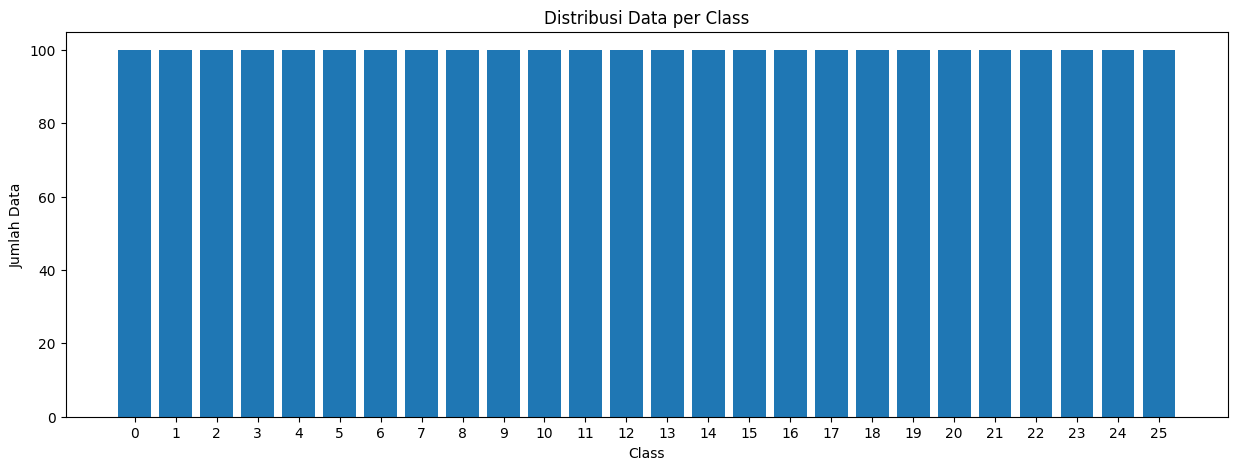

In [36]:
unique_classes, counts = np.unique(y_subset, return_counts=True)

plt.figure(figsize=(15, 5))
plt.bar(unique_classes, counts)
plt.xlabel('Class')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Data per Class')
plt.xticks(unique_classes)
plt.show()

In [37]:
X_subset, y_subset = shuffle(X_subset, y_subset, random_state=42)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, 
    y_subset, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_subset
)

print("Jumlah x_train:", len(X_train))
print("Jumlah y_train :", len(y_train))
print("Jumlah x_test :", len(X_test))
print("Jumlah y_test :", len(y_test))

Jumlah x_train: 2080
Jumlah y_train : 2080
Jumlah x_test : 520
Jumlah y_test : 520


# **2. Feature Extraction**

In [39]:
feature, hog_img = hog(X_train[0].reshape(28,28), 
                       orientations=9, 
                       pixels_per_cell=(4, 4), 
                       cells_per_block=(2,2), 
                       visualize=True, 
                       block_norm='L2'
                       )

feature.shape

(1296,)

<BarContainer object of 1296 artists>

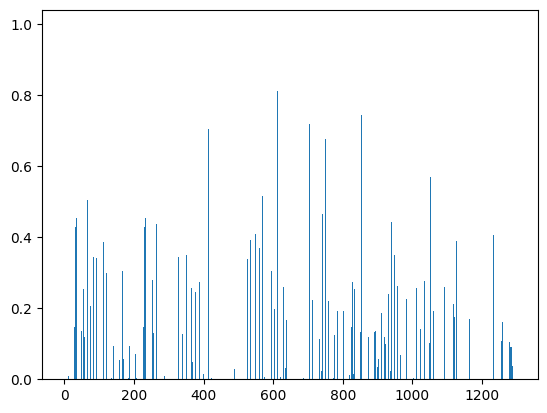

In [40]:
plt.bar(list(range(feature.shape[0])), feature)

In [41]:
def hog_features(images):
    features = []
    for image in images:
        feature = hog(image.reshape(28, 28), orientations=9,
                      pixels_per_cell=(4, 4),
                      cells_per_block=(2, 2),
                      block_norm='L2')
        features.append(feature)
    return np.array(features)

In [42]:
X_train_hog = hog_features(X_train)
X_test_hog = hog_features(X_test)

In [43]:
print("X_train_hog shape:", X_train_hog.shape)
print("X_test_hog shape :", X_test_hog.shape)

X_train_hog shape: (2080, 1296)
X_test_hog shape : (520, 1296)


# **3. Classification**

In [44]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], #regularization 
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], # kernel type
    'gamma': ['scale', 'auto'] # gamma
}

In [45]:
svm = SVC()
grid_search = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1, verbose=2)

In [46]:
grid_search.fit(X_train_hog, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,100


In [47]:
best_model = grid_search.best_estimator_ 

# **4. Evaluation**

In [48]:
loo = LeaveOneOut()

In [49]:
y_pred_loo_train = cross_val_predict(best_model, X_train_hog, y_train, cv=loo)
y_pred_loo_test = cross_val_predict(best_model, X_test_hog, y_test, cv=loo)

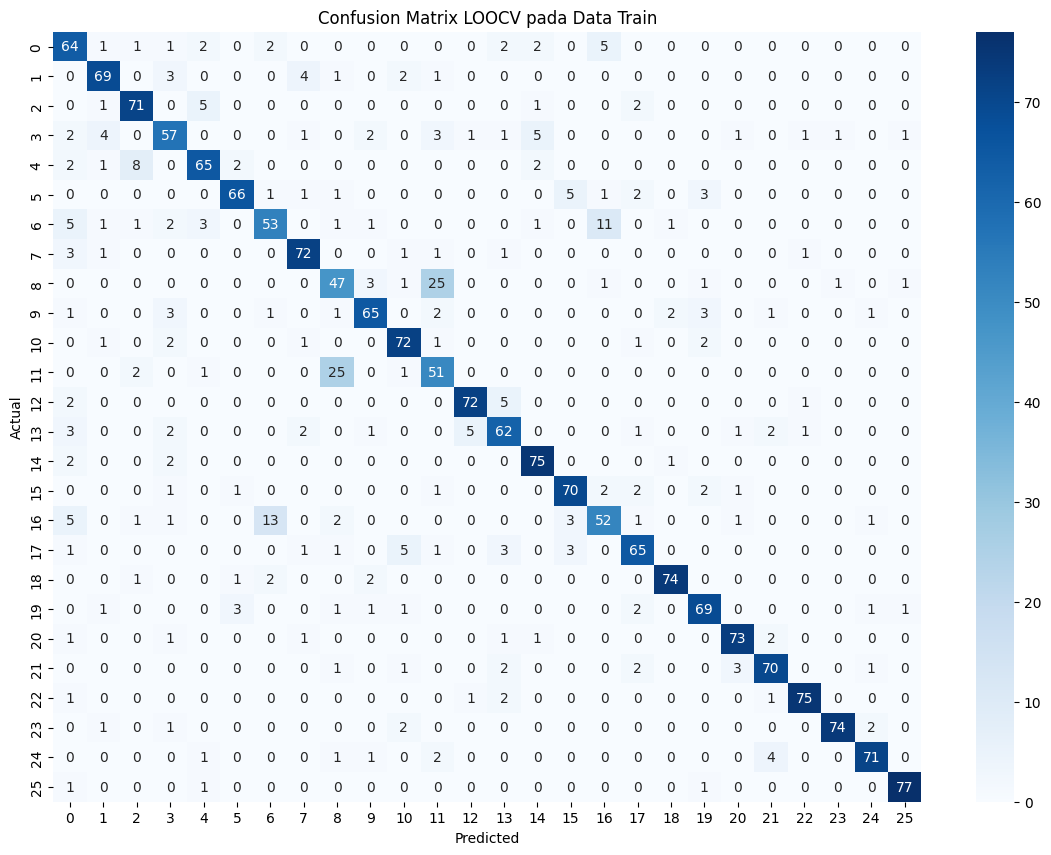

In [50]:
cm_train = confusion_matrix(y_train, y_pred_loo_train)
plt.figure(figsize=(14, 10))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix LOOCV pada Data Train")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
print(classification_report(y_train, y_pred_loo_train))

              precision    recall  f1-score   support

           0       0.69      0.80      0.74        80
           1       0.85      0.86      0.86        80
           2       0.84      0.89      0.86        80
           3       0.75      0.71      0.73        80
           4       0.83      0.81      0.82        80
           5       0.90      0.82      0.86        80
           6       0.74      0.66      0.70        80
           7       0.87      0.90      0.88        80
           8       0.57      0.59      0.58        80
           9       0.86      0.81      0.83        80
          10       0.84      0.90      0.87        80
          11       0.58      0.64      0.61        80
          12       0.91      0.90      0.91        80
          13       0.78      0.78      0.78        80
          14       0.86      0.94      0.90        80
          15       0.86      0.88      0.87        80
          16       0.72      0.65      0.68        80
          17       0.83    

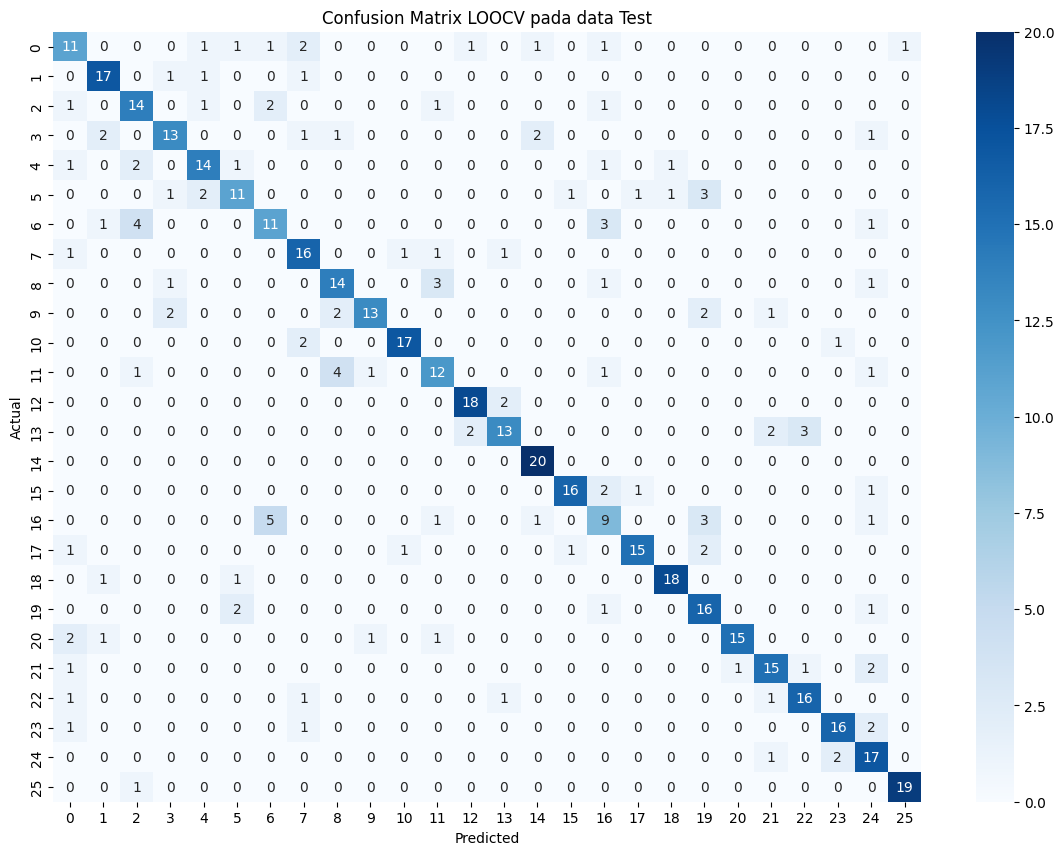

In [52]:
cm_test = confusion_matrix(y_test, y_pred_loo_test)
plt.figure(figsize=(14, 10))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix LOOCV pada data Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [53]:
print(classification_report(y_test, y_pred_loo_test))

              precision    recall  f1-score   support

           0       0.55      0.55      0.55        20
           1       0.77      0.85      0.81        20
           2       0.64      0.70      0.67        20
           3       0.72      0.65      0.68        20
           4       0.74      0.70      0.72        20
           5       0.69      0.55      0.61        20
           6       0.58      0.55      0.56        20
           7       0.67      0.80      0.73        20
           8       0.67      0.70      0.68        20
           9       0.87      0.65      0.74        20
          10       0.89      0.85      0.87        20
          11       0.63      0.60      0.62        20
          12       0.86      0.90      0.88        20
          13       0.76      0.65      0.70        20
          14       0.83      1.00      0.91        20
          15       0.89      0.80      0.84        20
          16       0.45      0.45      0.45        20
          17       0.88    

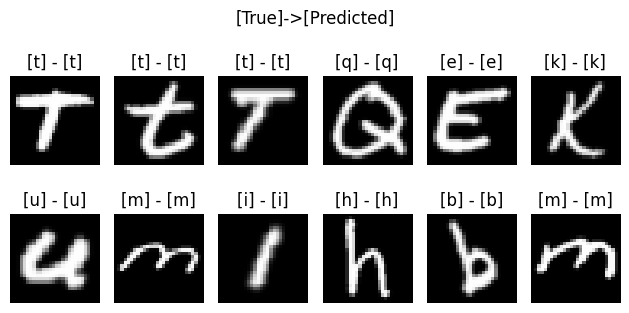

In [54]:
indices = random.sample(range(len(X_test)), 12)

for i, idx in enumerate(indices):
    img = X_test[idx].reshape(28, 28).T 
    true_label = y_test[idx] 
    pred_label = y_test[idx] 

    plt.subplot(3, 6, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"[{chr(true_label + 97)}] - [{chr(pred_label + 97)}]") 
    plt.axis('off')

plt.suptitle("[True]->[Predicted]")
plt.tight_layout()
plt.show()